#import


In [1]:
pip install optuna darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
from flask import Flask, jsonify, request
from darts import TimeSeries
from darts.models import NBEATSModel
from darts.dataprocessing.transformers import Scaler
import torch
from flask import Flask, jsonify, request
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from darts.metrics import mae, rmse

#MODELING

do not run this


In [3]:
dataset = pd.read_csv("dataset.csv")
dataset.head()

,Year,Solid fuel - industry,Solid fuel - transport,Solid fuel - domestic,Solid fuel - services,Solid fuel - total,Petroleum - industry,Petroleum - transport,Petroleum - domestic,Petroleum - services,...,Electricity - industry,Electricity - transport,Electricity - domestic,Electricity - services,Electricity - total,Total - industry,Total - transport,Total - domestic,Total - services,Total - total
0,1970,"45,573",899,"38,262","14,260","98,994","37,758","31,515","9,798","13,296",...,"2,820",107,"2,976","1,532","7,435","88,959","32,522","58,015","30,599","210,095"
1,1971,"40,284",745,"34,486","12,216","87,732","37,250","31,998","10,648","13,647",...,"2,846",107,"3,127","1,593","7,672","86,599","32,858","58,029","29,680","207,167"
2,1972,"34,345",584,"31,165","10,753","76,847","38,944","33,014","13,426","14,828",...,"2,925",106,"3,474","1,697","8,203","86,512","33,726","60,633","30,245","211,116"
3,1973,"37,748",597,"33,028","11,862","83,235","38,626","35,425","12,826","14,623",...,"2,840",92,"3,238","1,626","7,797","91,419","36,122","61,899","31,067","220,506"
4,1974,"32,206",552,"30,419","10,101","73,278","34,362","34,036","12,782","13,147",...,"3,311",119,"4,046","1,850","9,326","84,176","34,740","62,528","28,948","210,391"


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Year                           54 non-null     int64 
 1   Solid fuel - industry          54 non-null     object
 2   Solid fuel - transport         54 non-null     object
 3   Solid fuel - domestic          54 non-null     object
 4   Solid fuel - services          54 non-null     object
 5   Solid fuel - total             54 non-null     object
 6   Petroleum - industry           54 non-null     object
 7   Petroleum - transport          54 non-null     object
 8   Petroleum - domestic           54 non-null     object
 9   Petroleum - services           54 non-null     object
 10  Petroleum - total              54 non-null     object
 11  Natural gas - industry         54 non-null     object
 12  Natural gas - transport        54 non-null     int64 
 13  Natural

In [5]:
total_columns = [col for col in dataset.columns if col.endswith('- total')]

In [6]:
# Filter the dataset to include only the year and '-total' columns
filtered_data = dataset[['Year'] + total_columns]

In [7]:
total_columns

['Solid fuel - total',
 'Petroleum - total',
 'Natural gas - total',
 'Bioenergy & waste - total',
 'Electricity - total',
 'Total - total']

In [8]:
# Melt the dataset
melted_data = pd.melt(filtered_data, id_vars=["Year"], var_name="Fuel_Type", value_name="Consumption")

# Convert 'Year' to datetime type
melted_data['Year'] = pd.to_datetime(melted_data['Year'], format='%Y')

# Display the melted data
melted_data.head()

,Year,Fuel_Type,Consumption
0,1970-01-01,Solid fuel - total,"98,994"
1,1971-01-01,Solid fuel - total,"87,732"
2,1972-01-01,Solid fuel - total,"76,847"
3,1973-01-01,Solid fuel - total,"83,235"
4,1974-01-01,Solid fuel - total,"73,278"


In [9]:
melted_data['Consumption'] = melted_data['Consumption'].replace({',': ''}, regex=True)
melted_data['Consumption'] = pd.to_numeric(melted_data['Consumption'], errors='coerce')

In [10]:
melted_data

,Year,Fuel_Type,Consumption
0,1970-01-01,Solid fuel - total,98994
1,1971-01-01,Solid fuel - total,87732
2,1972-01-01,Solid fuel - total,76847
3,1973-01-01,Solid fuel - total,83235
4,1974-01-01,Solid fuel - total,73278
...,...,...,...
319,2019-01-01,Total - total,183866
320,2020-01-01,Total - total,164694
321,2021-01-01,Total - total,170869
322,2022-01-01,Total - total,168618


[I 2025-05-31 16:42:34,034] A new study created in memory with name: no-name-a7142842-6ec5-404f-8047-982589957570
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=254` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

[I 2025-05-31 16:46:00,170] Trial 0 finished with value: 93.79930169212972 and parameters: {'input_chunk_length': 61, 'output_chunk_length': 6, 'n_epochs': 254, 'batch_size': 18}. Best is trial 0 with value: 93.79930169212972.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=363` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

[I 2025-05-31 16:48:11,219] Trial 1 finished with value: 85.03256279552896 and parameters: {'input_chunk_length': 62, 'output_chunk_length': 6, 'n_epochs': 363, 'batch_size': 49}. Best is trial 1 with value: 85.03256279552896.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=127` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

[I 2025-05-31 18:00:50,924] Trial 49 finished with value: 60.621388956257995 and parameters: {'input_chunk_length': 96, 'output_chunk_length': 12, 'n_epochs': 146, 'batch_size': 36}. Best is trial 10 with value: 20.321466011372795.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | 

Best trial:
  Value (MAPE): 20.321466011372795
  Params: {'input_chunk_length': 115, 'output_chunk_length': 13, 'n_epochs': 115, 'batch_size': 30}


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=115` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

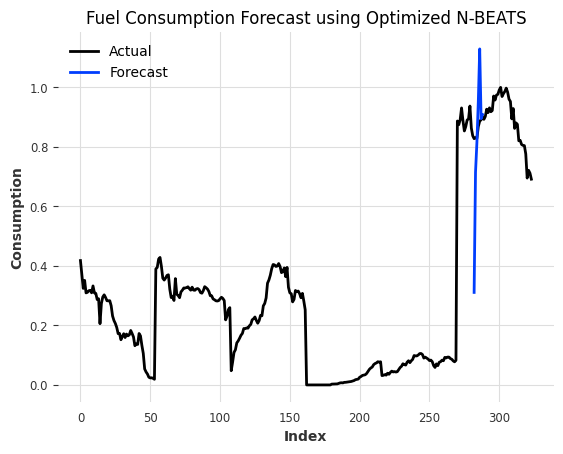

In [12]:
# Step 1: Prepare Data (use index as time)
melted_data['Index'] = melted_data.index  # Adding index as a column for TimeSeries

# Step 2: Convert to TimeSeries using the index as time
series = TimeSeries.from_dataframe(melted_data, time_col="Index", value_cols="Consumption")
# Step 4: Normalization
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

# Step 5: Train/Test split (using last 42 values for validation)
train, val = series_scaled[:-42], series_scaled[-42:]

# Objective function for Optuna
def objective(trial):
    # Hyperparameter tuning
    input_chunk_length = trial.suggest_int('input_chunk_length', 24, 120)
    output_chunk_length = trial.suggest_int('output_chunk_length', 6, 24)
    n_epochs = trial.suggest_int('n_epochs', 100, 500)
    batch_size = trial.suggest_int('batch_size', 16, 64)

    # Step 6: N-BEATS model with parameters from Optuna
    model = NBEATSModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=output_chunk_length,
        n_epochs=n_epochs,
        random_state=42,
        batch_size=batch_size
    )

    # Step 7: Fit the model
    model.fit(train, verbose=False)

    # Step 8: Evaluate the model using validation data
    forecast = model.predict(n=len(val))
    # Calculate the Mean Absolute Percentage Error (MAPE) as a performance metric
    mape_value = np.mean(np.abs((forecast.values() - val.values()) / val.values())) * 100
    return mape_value

# Step 9: Set up Optuna study and optimize
study = optuna.create_study(direction='minimize')  # We want to minimize the MAPE
study.optimize(objective, n_trials=50)  # Number of trials (you can increase this for more thorough search)

# Step 10: Display the best parameters found by Optuna
print("Best trial:")
best_trial = study.best_trial
print(f"  Value (MAPE): {best_trial.value}")
print(f"  Params: {best_trial.params}")

# Step 11: Train the model with the best parameters
best_params = best_trial.params
best_model = NBEATSModel(
    input_chunk_length=best_params['input_chunk_length'],
    output_chunk_length=best_params['output_chunk_length'],
    n_epochs=best_params['n_epochs'],
    batch_size=best_params['batch_size'],
    random_state=42
)

best_model.fit(train, verbose=True)

# Step 12: Forecasting using the best model
forecast = best_model.predict(n=7)

# Step 13: Plotting the results
series_scaled.plot(label="Actual")
forecast.plot(label="Forecast")
plt.xlabel("Index")
plt.ylabel("Consumption")
plt.title("Fuel Consumption Forecast using Optimized N-BEATS")
plt.legend()
plt.show()


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 6.9 M  | train
-------------------------------------------------------------
6.9 M     Trainable params
2.0 K     Non-trainable params
6.9 M     Total params
27.649    Total estimated model params size (MB)
396       Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=115` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

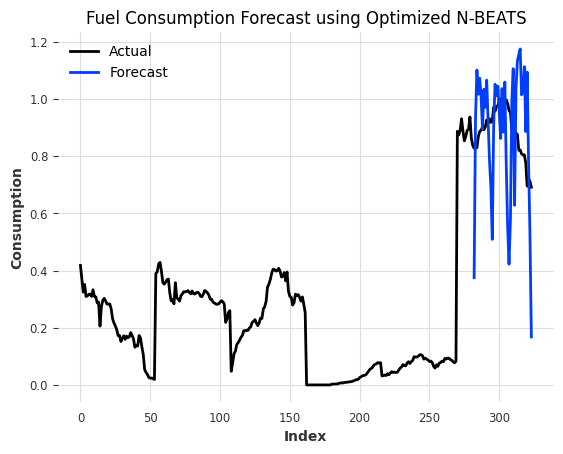

MAE: 0.1976803873359126
RMSE: 0.24241716020370804


In [15]:
param = {'input_chunk_length': 115, 'output_chunk_length': 13, 'n_epochs': 115, 'batch_size': 30}
best_model = NBEATSModel(
    **param
)

best_model.fit(train, verbose=True)

# Step 12: Forecasting using the best model
forecast = best_model.predict(n=42)
# Step 13: Plotting the results
series_scaled.plot(label="Actual")
forecast.plot(label="Forecast")
plt.xlabel("Index")
plt.ylabel("Consumption")
plt.title("Fuel Consumption Forecast using Optimized N-BEATS")
plt.legend()
plt.show()

print(f"MAE: {mae(val, forecast)}")
print(f"RMSE: {rmse(val, forecast)}")


In [16]:
best_model.save("nbeats_model.pth")

In [20]:
# Step 1: Prepare Data (use index as time)
melted_data['Index'] = melted_data.index  # Adding index as a column for TimeSeries

# Step 2: Convert to TimeSeries using the index as time
series = TimeSeries.from_dataframe(melted_data, time_col="Index", value_cols="Consumption")
# Step 4: Normalization
scaler = Scaler()
series_scaled = scaler.fit_transform(series)

#API IS FROM HERE

In [19]:
app = Flask(__name__)

# Load the trained model
def load_model():
    best_model = NBEATSModel.load("nbeats_model.pth")
    return best_model

# Prediction endpoint
@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Get the data from the request
        data = request.get_json()

        # Extract necessary input from the request
        input_data = np.array(data["input"]).reshape(-1, 1)  # Input data
        n_predictions = data.get("n", 7)
        input_series = TimeSeries.from_values(input_data)
        scaler = Scaler()
        input_series_scaled = scaler.fit_transform(input_series)

        # Get the model and make the prediction
        model = load_model()
        forecast = model.predict(n=n_predictions)  # Predict `n_predictions` future values

        # Inverse transform the forecast
        forecast_values = scaler.inverse_transform(forecast.values())

        # Return the predicted values as a JSON response
        return jsonify({'prediction': forecast_values.tolist()})

    except Exception as e:
        return jsonify({'error': str(e)})

# Run the Flask application
if __name__ == '__main__':
    # Print the URL of the API after the app starts
    print("Starting the Flask API...")
    print(f"API is running at: http://127.0.0.1:5000/predict")
    app.run(debug=True)

Starting the Flask API...
API is running at: http://127.0.0.1:5000/predict
 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with stat
